<a href="https://colab.research.google.com/github/gustavocxavier/analise-de-dados-para-negocios/blob/main/DFC_MQ_Aula_2026_07_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multicolinearidade, Heterocedasticidade e Seleção de Variáveis

## Disciplina: Métodos Quantitativos para Ciências Contábeis
## Aula: Laboratório guiado de 20/07/2026 - Unidade III, Tópico 2

### Uso sugerido no Google Colab:
1. Abra um notebook novo.
2. Cole este script em uma célula, ou envie o arquivo para o Colab.
3. Execute as células passo a passo com os alunos.

### Base de dados e Pergunta de Negócio

**Base de dados:** CEOSAL2 (Wooldridge), amplamente usada em cursos de econometria para ilustrar multicolinearidade em contexto de negócios.

**Pergunta de negócio:** o que explica o salário anual do CEO — o tamanho da empresa (vendas, valor de mercado), a lucratividade ou o tempo no cargo?

In [1]:
import sys
import subprocess

def instalar_pacote(pacote, nome_import=None):
    """Instala pacote no Colab apenas se ele não estiver disponível."""
    nome_import = nome_import or pacote
    try:
        __import__(nome_import)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pacote])


instalar_pacote("wooldridge")
instalar_pacote("statsmodels")
instalar_pacote("seaborn")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import wooldridge

## 1. Carregar a base e conhecer as variáveis

In [2]:
dados = wooldridge.data("ceosal2")
print(wooldridge.data("ceosal2", description=True))

colunas_uso = ["salary", "lsalary", "sales", "lsales", "mktval", "lmktval",
               "profits", "profmarg", "ceoten"]
dados = dados[colunas_uso].dropna()

print("\nPrimeiras linhas da base:")
display(dados.head())

print("\nEstatísticas descritivas:")
display(dados[["salary", "sales", "mktval", "profits", "profmarg", "ceoten"]].describe())

name of dataset: ceosal2
no of variables: 15
no of observations: 177

+----------+--------------------------------+
| variable | label                          |
+----------+--------------------------------+
| salary   | 1990 compensation, $1000s      |
| age      | in years                       |
| college  | =1 if attended college         |
| grad     | =1 if attended graduate school |
| comten   | years with company             |
| ceoten   | years as ceo with company      |
| sales    | 1990 firm sales, millions      |
| profits  | 1990 profits, millions         |
| mktval   | market value, end 1990, mills. |
| lsalary  | log(salary)                    |
| lsales   | log(sales)                     |
| lmktval  | log(mktval)                    |
| comtensq | comten^2                       |
| ceotensq | ceoten^2                       |
| profmarg | profits as % of sales          |
+----------+--------------------------------+

See CEOSAL1.RAW
None

Primeiras linhas da base:


,salary,lsalary,sales,lsales,mktval,lmktval,profits,profmarg,ceoten
0,1161,7.057037,6200.0,8.732305,23200.0,10.051908,966,15.580646,2
1,600,6.396930,283.0,5.645447,1100.0,7.003066,48,16.961130,10
2,379,5.937536,169.0,5.129899,1100.0,7.003066,40,23.668638,3
3,651,6.478509,1100.0,7.003066,1000.0,6.907755,-54,-4.909091,22
4,497,6.208590,351.0,5.860786,387.0,5.958425,28,7.977208,6



Estatísticas descritivas:


,salary,sales,mktval,profits,profmarg,ceoten
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,865.864407,3529.463277,3600.316384,207.830508,6.420110,7.954802
std,587.589281,6088.654193,6442.276020,404.454296,17.860744,7.150826
min,100.000000,29.000000,387.000000,-463.000000,-203.076920,0.000000
25%,471.000000,561.000000,644.000000,34.000000,4.230769,3.000000
50%,707.000000,1400.000000,1200.000000,63.000000,6.833713,6.000000
75%,1119.000000,3500.000000,3500.000000,208.000000,10.947369,11.000000
max,5299.000000,51300.000000,45400.000000,2700.000000,47.457626,37.000000


## 2. Sales, valor de mercado e lucro medem coisas parecidas?


Correlação entre possíveis medidas de 'tamanho/sucesso' da empresa:


,sales,mktval,profits
sales,1.00,0.75,0.80
mktval,0.75,1.00,0.92
profits,0.80,0.92,1.00


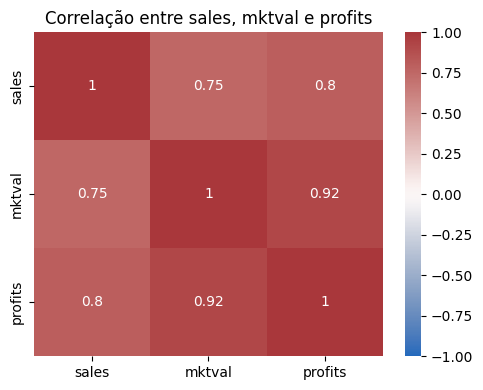

In [3]:
print("\nCorrelação entre possíveis medidas de 'tamanho/sucesso' da empresa:")
correlacoes = dados[["sales", "mktval", "profits"]].corr()
display(correlacoes.round(2))

plt.figure(figsize=(5, 4))
sns.heatmap(correlacoes, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlação entre sales, mktval e profits")
plt.tight_layout()
plt.show()

## 3. Modelo "ingênuo": todas as variáveis de tamanho juntas

In [4]:
modelo_ingenuo = smf.ols("salary ~ sales + mktval + profits + ceoten", data=dados).fit()
print("\nModelo ingênuo: salary ~ sales + mktval + profits + ceoten")
print(modelo_ingenuo.summary())

print(
    "\nObserve o coeficiente e o valor-p de 'profits'. Empresas mais lucrativas "
    "pagam CEOs melhor, mas o coeficiente pode sair pouco significativo ou "
    "com sinal pouco intuitivo. Isso não significa que lucro não importa — "
    "pode ser sintoma de multicolinearidade."
)


Modelo ingênuo: salary ~ sales + mktval + profits + ceoten
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     10.85
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           7.28e-08
Time:                        22:14:51   Log-Likelihood:                -1359.3
No. Observations:                 177   AIC:                             2729.
Df Residuals:                     172   BIC:                             2744.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## 4. Diagnóstico de multicolinearidade: VIF

In [5]:
explicativas = dados[["sales", "mktval", "profits", "ceoten"]].copy()
X_vif = sm.add_constant(explicativas)

vif = pd.DataFrame({
    "variável": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif = vif[vif["variável"] != "const"].reset_index(drop=True)

print("\nFator de Inflação da Variância (VIF) - modelo ingênuo:")
display(vif.round(2))

print(
    "\nRegra prática usada em aula: VIF acima de 5 já é sinal de alerta; "
    "alguns autores usam o corte de 10. Valores altos em 'sales' e 'mktval' "
    "confirmam que elas carregam informação muito parecida."
)


Fator de Inflação da Variância (VIF) - modelo ingênuo:


,variável,VIF
0,sales,2.80
1,mktval,6.46
2,profits,7.63
3,ceoten,1.01



Regra prática usada em aula: VIF acima de 5 já é sinal de alerta; alguns autores usam o corte de 10. Valores altos em 'sales' e 'mktval' confirmam que elas carregam informação muito parecida.


## 5. Um modelo mais parcimonioso

In [6]:
modelo_parcimonioso = smf.ols("salary ~ mktval + profmarg + ceoten", data=dados).fit()
print("\nModelo parcimonioso: salary ~ mktval + profmarg + ceoten")
print(modelo_parcimonioso.summary())

comparacao = pd.DataFrame({
    "Modelo ingênuo (4 variáveis)": [
        modelo_ingenuo.rsquared,
        modelo_ingenuo.rsquared_adj,
    ],
    "Modelo parcimonioso (3 variáveis)": [
        modelo_parcimonioso.rsquared,
        modelo_parcimonioso.rsquared_adj,
    ],
}, index=["R²", "R² ajustado"])

print("\nComparação de ajuste entre os dois modelos:")
display(comparacao.round(3))


Modelo parcimonioso: salary ~ mktval + profmarg + ceoten
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     13.42
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           6.50e-08
Time:                        22:14:53   Log-Likelihood:                -1360.7
No. Observations:                 177   AIC:                             2729.
Df Residuals:                     173   BIC:                             2742.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

,Modelo ingênuo (4 variáveis),Modelo parcimonioso (3 variáveis)
R²,0.201,0.189
R² ajustado,0.183,0.175


## 6. Heterocedasticidade: nível vs. logaritmo do salário

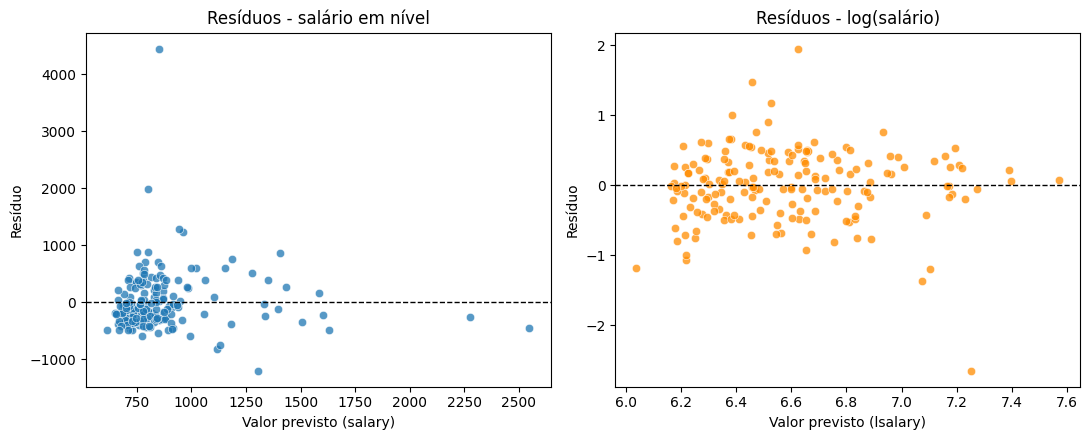


Compare os dois gráficos: no modelo em nível, os resíduos tendem a 'abrir em funil' para CEOs de empresas maiores. No modelo em log, a dispersão costuma ficar mais uniforme. Isso ilustra por que a transformação logarítmica é uma resposta comum à heterocedasticidade em variáveis monetárias com grande variação de escala.


In [7]:
dados["previsto_nivel"] = modelo_parcimonioso.fittedvalues
dados["residuo_nivel"] = modelo_parcimonioso.resid

modelo_log = smf.ols("lsalary ~ lmktval + profmarg + ceoten", data=dados).fit()
dados["previsto_log"] = modelo_log.fittedvalues
dados["residuo_log"] = modelo_log.resid

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))

sns.scatterplot(data=dados, x="previsto_nivel", y="residuo_nivel", ax=eixos[0], alpha=0.75)
eixos[0].axhline(0, color="black", linestyle="--", linewidth=1)
eixos[0].set_title("Resíduos - salário em nível")
eixos[0].set_xlabel("Valor previsto (salary)")
eixos[0].set_ylabel("Resíduo")

sns.scatterplot(data=dados, x="previsto_log", y="residuo_log", ax=eixos[1], alpha=0.75, color="darkorange")
eixos[1].axhline(0, color="black", linestyle="--", linewidth=1)
eixos[1].set_title("Resíduos - log(salário)")
eixos[1].set_xlabel("Valor previsto (lsalary)")
eixos[1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()

print(
    "\nCompare os dois gráficos: no modelo em nível, os resíduos tendem a "
    "'abrir em funil' para CEOs de empresas maiores. No modelo em log, a "
    "dispersão costuma ficar mais uniforme. Isso ilustra por que a "
    "transformação logarítmica é uma resposta comum à heterocedasticidade "
    "em variáveis monetárias com grande variação de escala."
)

## 7. Autocorrelação - por que não testamos aqui

In [8]:
print(
    "\nCEOSAL2 é uma base de corte transversal: cada linha é uma empresa "
    "diferente, sem ordem temporal. Não faz sentido testar autocorrelação "
    "dos resíduos nessa estrutura de dados. Autocorrelação será retomada "
    "com dados em série temporal nas aulas de 27/07 e 29/07."
)


CEOSAL2 é uma base de corte transversal: cada linha é uma empresa diferente, sem ordem temporal. Não faz sentido testar autocorrelação dos resíduos nessa estrutura de dados. Autocorrelação será retomada com dados em série temporal nas aulas de 27/07 e 29/07.


## 8. Quadro-resumo para a decisão de qual modelo usar

In [9]:
vif_parcimonioso = pd.DataFrame({
    "variável": sm.add_constant(dados[["mktval", "profmarg", "ceoten"]]).columns,
    "VIF": [
        variance_inflation_factor(sm.add_constant(dados[["mktval", "profmarg", "ceoten"]]).values, i)
        for i in range(sm.add_constant(dados[["mktval", "profmarg", "ceoten"]]).shape[1])
    ],
})
vif_parcimonioso = vif_parcimonioso[vif_parcimonioso["variável"] != "const"]

resumo = pd.DataFrame({
    "Modelo": ["Ingênuo (sales+mktval+profits+ceoten)", "Parcimonioso (mktval+profmarg+ceoten)"],
    "R² ajustado": [modelo_ingenuo.rsquared_adj, modelo_parcimonioso.rsquared_adj],
    "VIF máximo": [vif["VIF"].max(), vif_parcimonioso["VIF"].max()],
})

print("\nQuadro-resumo para discussão final:")
display(resumo.round(3))

print(
    "\nPergunta para a turma responder em uma frase: qual modelo vocês "
    "recomendariam para explicar o salário do CEO, e por quê? Considerem "
    "ajuste, multicolinearidade e interpretabilidade dos coeficientes, não "
    "apenas o R²."
)


Quadro-resumo para discussão final:


,Modelo,R² ajustado,VIF máximo
0,Ingênuo (sales+mktval+profits+ceoten),0.183,7.626
1,Parcimonioso (mktval+profmarg+ceoten),0.175,1.007



Pergunta para a turma responder em uma frase: qual modelo vocês recomendariam para explicar o salário do CEO, e por quê? Considerem ajuste, multicolinearidade e interpretabilidade dos coeficientes, não apenas o R².
